In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GATConv
from torch_geometric.transforms import NormalizeFeatures
from sklearn.metrics import accuracy_score
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

Датасет

In [2]:
dataset = Planetoid(
    root='data/Cora',
    name='Cora',
    transform=NormalizeFeatures()
)

data = dataset[0]

print(f'Количество узлов: {data.num_nodes}')
print(f'Количество рёбер: {data.num_edges}')
print(f'Количество признаков на узел: {dataset.num_node_features}')
print(f'Количество классов: {dataset.num_classes}')

Количество узлов: 2708
Количество рёбер: 10556
Количество признаков на узел: 1433
Количество классов: 7


Проверка сбалансированности классов в датасете

In [3]:
train_labels = data.y[data.train_mask]
train_counts = torch.bincount(train_labels)

print("\nTrain распределение:")
for i, count in enumerate(train_counts):
    print(f"Класс {i}: {count.item()}")

test_labels = data.y[data.test_mask]
test_counts = torch.bincount(test_labels)

print("\nTest распределение:")
for i, count in enumerate(test_counts):
    print(f"Класс {i}: {count.item()}")


Train распределение:
Класс 0: 20
Класс 1: 20
Класс 2: 20
Класс 3: 20
Класс 4: 20
Класс 5: 20
Класс 6: 20

Test распределение:
Класс 0: 130
Класс 1: 91
Класс 2: 144
Класс 3: 319
Класс 4: 149
Класс 5: 103
Класс 6: 64


Определение модели

In [4]:
class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8):
        super(GAT, self).__init__()

        self.gat1 = GATConv(
            in_channels,
            hidden_channels,
            heads=heads,
            dropout=0.6
        )

        self.gat2 = GATConv(
            hidden_channels * heads,
            out_channels,
            heads=1,
            concat=False,
            dropout=0.6
        )

    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.gat2(x, edge_index)
        return x

Инициализация модели

In [5]:
model = GAT(
    dataset.num_node_features,
    8,
    dataset.num_classes,
    heads=8
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

Обучение

In [6]:
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

Тестирование

In [7]:
def test():
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    acc = accuracy_score(
        data.y[data.test_mask].cpu(),
        pred[data.test_mask].cpu()
    )
    return acc

Цикл обучения

In [8]:
for epoch in range(1, 201):
    loss = train()
    if epoch % 20 == 0:
        acc = test()
        print(f"Epoch {epoch}, Loss: {loss:.4f}, Test Acc: {acc:.4f}")

print("Финальная точность:", test())

Epoch 20, Loss: 1.8079, Test Acc: 0.8210
Epoch 40, Loss: 1.5943, Test Acc: 0.7670
Epoch 60, Loss: 1.2590, Test Acc: 0.8140
Epoch 80, Loss: 1.0962, Test Acc: 0.8250
Epoch 100, Loss: 0.9731, Test Acc: 0.8140
Epoch 120, Loss: 0.8844, Test Acc: 0.8180
Epoch 140, Loss: 0.7355, Test Acc: 0.8190
Epoch 160, Loss: 0.8075, Test Acc: 0.8230
Epoch 180, Loss: 0.7183, Test Acc: 0.8140
Epoch 200, Loss: 0.6372, Test Acc: 0.8250
Финальная точность: 0.825


Оценка результатов классификации

In [9]:
model.eval()
with torch.no_grad():
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)

# Берём только test узлы
y_true = data.y[data.test_mask].cpu().numpy()
y_pred = pred[data.test_mask].cpu().numpy()

# Метрики
accuracy = accuracy_score(y_true, y_pred)
print("\nAccuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

# Матрица ошибок
cm = confusion_matrix(y_true, y_pred)


Accuracy: 0.825

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.79      0.73       130
           1       0.79      0.85      0.81        91
           2       0.89      0.92      0.91       144
           3       0.91      0.80      0.85       319
           4       0.80      0.85      0.82       149
           5       0.86      0.78      0.82       103
           6       0.70      0.81      0.75        64

    accuracy                           0.82      1000
   macro avg       0.81      0.83      0.81      1000
weighted avg       0.83      0.82      0.83      1000



Матрица ошибок

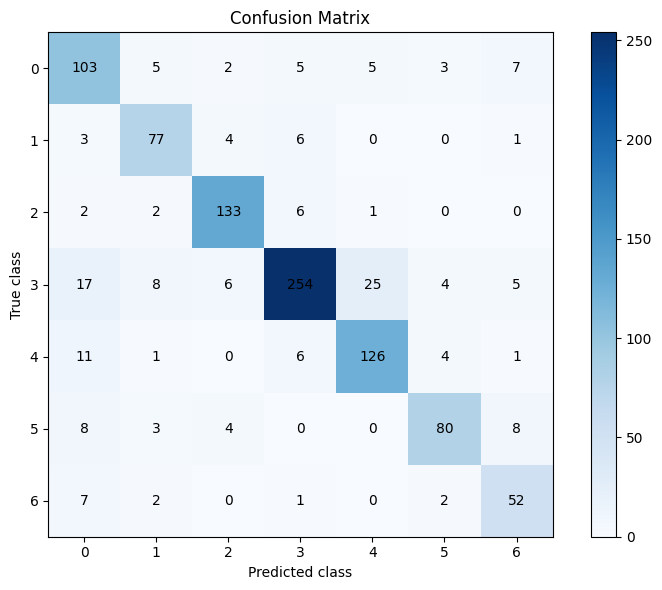

In [10]:
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i,
            cm[i, j],
            ha="center",
            va="center",
            color="black"
        )

plt.xticks(np.arange(cm.shape[0]))
plt.yticks(np.arange(cm.shape[0]))
plt.tight_layout()
plt.show()

Визуализация эмбидингов

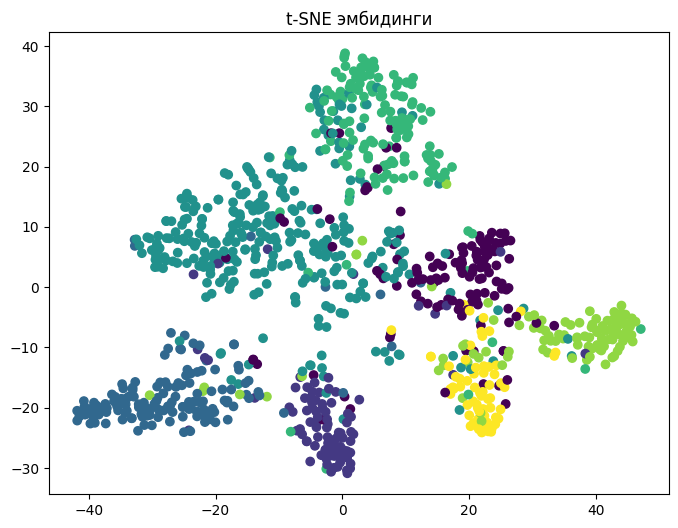

In [13]:
model.eval()
with torch.no_grad():
    embeddings = model.gat1(data.x, data.edge_index)

embeddings = embeddings[data.test_mask].cpu().numpy()
labels = data.y[data.test_mask].cpu().numpy()

tsne = TSNE(n_components=2, random_state=42)
emb_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(8,6))
plt.scatter(emb_2d[:,0], emb_2d[:,1], c=labels)
plt.title("t-SNE эмбидинги")
plt.show()

Эксперимент с разным количеством голов

In [12]:
heads = [1, 2, 4, 8, 16]

for head_num in heads:
    model = GAT(
        dataset.num_node_features,
        8,
        dataset.num_classes,
        heads=head_num
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
    criterion = nn.CrossEntropyLoss()

    print(f"\nКоличество голов памяти: {head_num}")
    for epoch in range(1, 201):
        loss = train()
        if epoch % 20 == 0:
            acc = test()
            print(f"Epoch {epoch}, Loss: {loss:.4f}, Test Acc: {acc:.4f}")
    
    print("Финальная точность:", test())


Количество голов памяти: 1
Epoch 20, Loss: 1.9124, Test Acc: 0.6940
Epoch 40, Loss: 1.8592, Test Acc: 0.7810
Epoch 60, Loss: 1.7983, Test Acc: 0.7930
Epoch 80, Loss: 1.7220, Test Acc: 0.7820
Epoch 100, Loss: 1.5571, Test Acc: 0.8030
Epoch 120, Loss: 1.5204, Test Acc: 0.8210
Epoch 140, Loss: 1.4564, Test Acc: 0.7880
Epoch 160, Loss: 1.5190, Test Acc: 0.8270
Epoch 180, Loss: 1.4833, Test Acc: 0.8080
Epoch 200, Loss: 1.3524, Test Acc: 0.8340
Финальная точность: 0.834

Количество голов памяти: 2
Epoch 20, Loss: 1.8842, Test Acc: 0.8160
Epoch 40, Loss: 1.7807, Test Acc: 0.7400
Epoch 60, Loss: 1.6896, Test Acc: 0.7880
Epoch 80, Loss: 1.5522, Test Acc: 0.7830
Epoch 100, Loss: 1.4045, Test Acc: 0.8100
Epoch 120, Loss: 1.3805, Test Acc: 0.7990
Epoch 140, Loss: 1.2847, Test Acc: 0.8110
Epoch 160, Loss: 1.1705, Test Acc: 0.8030
Epoch 180, Loss: 1.2290, Test Acc: 0.7980
Epoch 200, Loss: 1.1082, Test Acc: 0.8090
Финальная точность: 0.809

Количество голов памяти: 4
Epoch 20, Loss: 1.8565, Test Acc